<h1 style="font-size: 1.6rem; font-weight: bold">ITO 5217: Natural Language Processing</h1>
<h1 style="font-size: 1.6rem; font-weight: bold">Exercise: Basic Text Analysis and N-Gram Modelling</h1>
<p style="margin-top: 5px; margin-bottom: 5px;">Monash University Australia</p>
<p style="margin-top: 5px; margin-bottom: 5px;">Jupyter Notebook by: Tristan Sim Yook Min</p>
References: Information Source from Monash Faculty of Information Technology

---

### **Infographic Summary for the Basic Text Analysis Notebook**

<br>

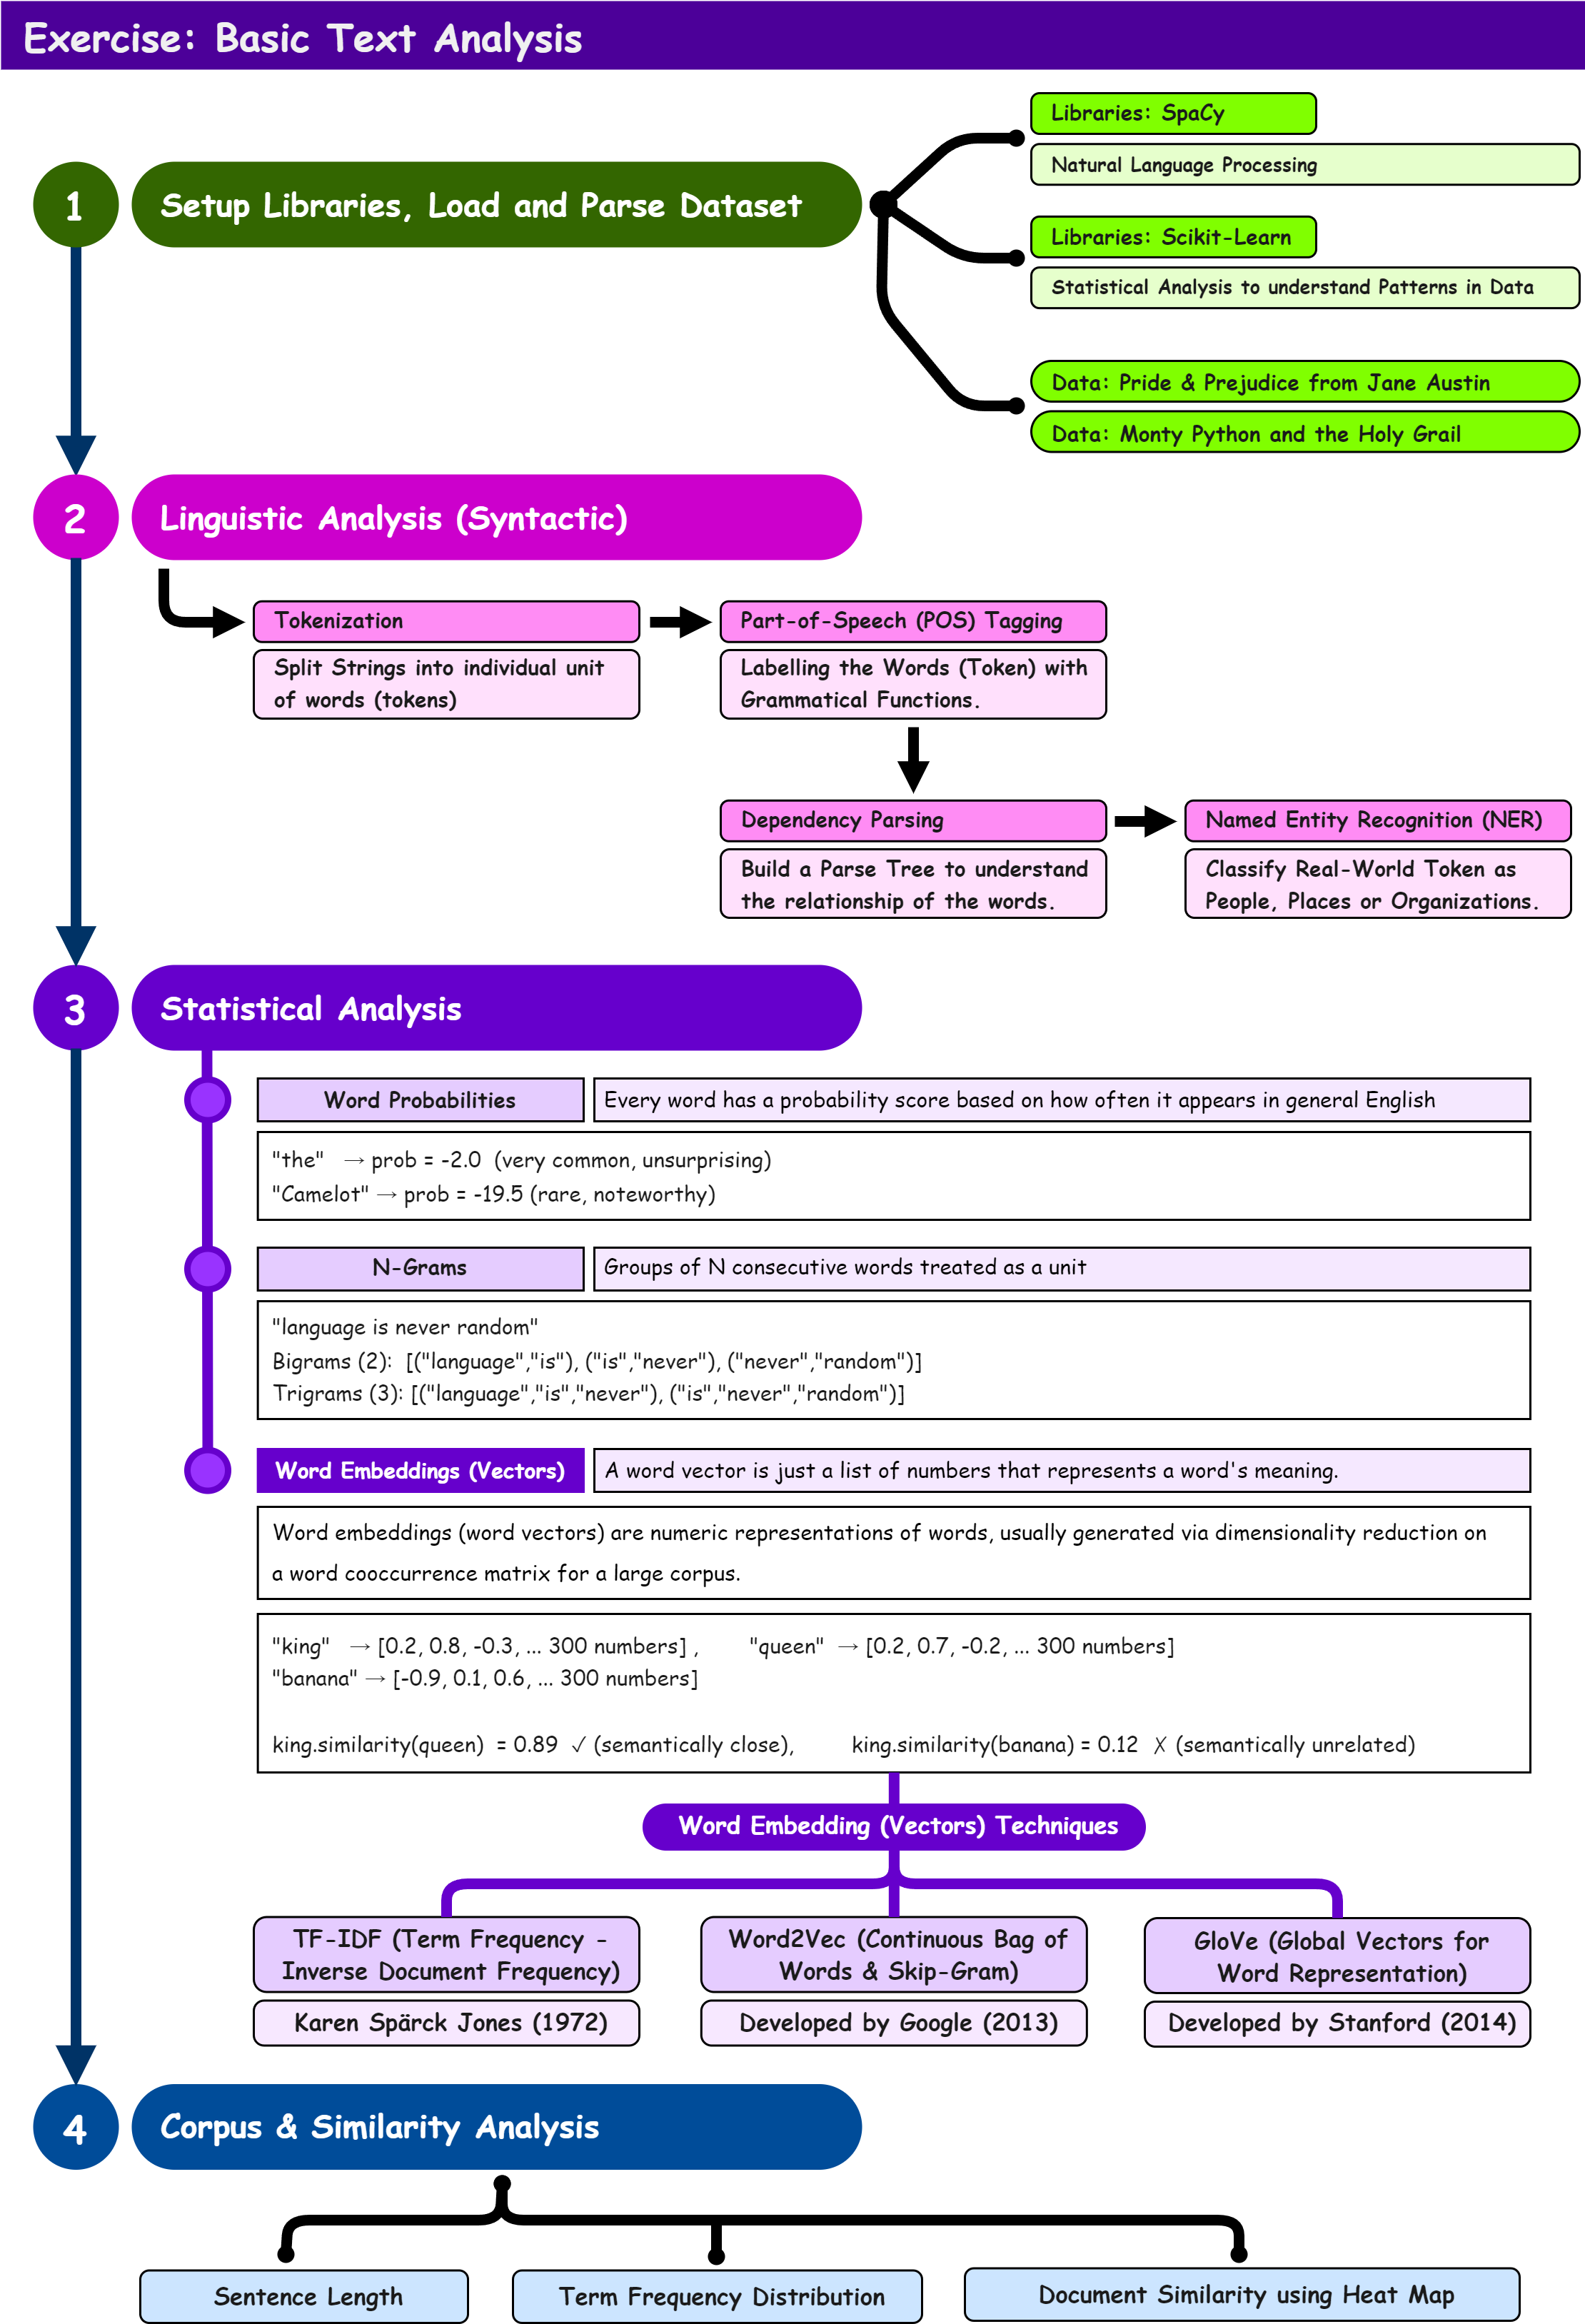

<br>

---

### **Exercise 1: Extract all the events from _Pride and Prejudice_**

In [3]:
# Task 1: Import Libraries
import spacy
import pandas as pd
import numpy as np
from collections import Counter
from glob import glob
import os
import matplotlib.pyplot as plt
import en_core_web_lg

In [4]:
# Task 2: Load the SpaCy Language Model (Natural Language Processing)
nlp = en_core_web_lg.load()

In [5]:
# Task 3: Load the Dataset ()

# Read the Raw Text from file
grail_raw = open('Text-Analysis/grail.txt', encoding='utf-8').read()
pride_raw = open('Text-Analysis/pride.txt', encoding='utf-8').read()

# Parse it using the NLP Model
grail = nlp(grail_raw)
pride = nlp(pride_raw)

In [6]:
# Task 4: Extract Events from Pride and Prejudice
# An event is a verb and its associated subject/object (Dependency Parsing)

events = []
for sent in pride.sents:
    for token in sent:
        if token.pos_ == 'VERB':
            subject = [w.text for w in token.children if w.dep_ == 'nsubj']
            obj     = [w.text for w in token.children if w.dep_ == 'dobj']
            if subject:
                events.append({
                    'verb':    token.lemma_,
                    'subject': subject[0],
                    'object':  obj[0] if obj else '-'
                })

# Print first 20 events
events_df = pd.DataFrame(events[:20])
print(events_df)

      verb subject     object
0     know  little          -
1      say    lady          -
2     hear     you          -
3    reply  Bennet          -
4     have      he          -
5   return     she          -
6     tell     she         me
7     make  Bennet     answer
8     want     you          -
9     take     who         it
10    want     You          -
11    have       I  objection
12    know     you          -
13     say    Long          -
14    come      he          -
15   agree      he          -
16  affect      it       them
17   reply  Bennet          -
18    know     You          -
19   think       I          -


---

### **Exercise 2: Make a lexical dispersion plot of the word "ni" in _Monty Python and the Holy Grail_. What does this tell us?**

A lexical dispersion plot shows where a word appears across the text:

For Example: "Beginning of script"

                    ↑ each x = one occurrence of "ni"


For "ni" specifically — the Knights Who Say "Ni" only appear in one section of the film, so you'd expect a cluster in the middle then silence.

In [7]:
# Task 1: Create a Function (Location) to Find the Target Word in the Sentence
# Needle: Target Word
# Haystack: Is the String of Sentences to Search From

def locations(needle, haystack):

    # Find the position of every word that matches our search term
    word_positions = []
    for word in haystack:
        if word.text.lower() == needle:
            word_positions.append(word.i)
    
    # Bin those positions into a histogram with 50 buckets
    histogram = np.histogram(word_positions, bins=50)
    
    return pd.Series(histogram[0])

<Figure size 1600x400 with 0 Axes>

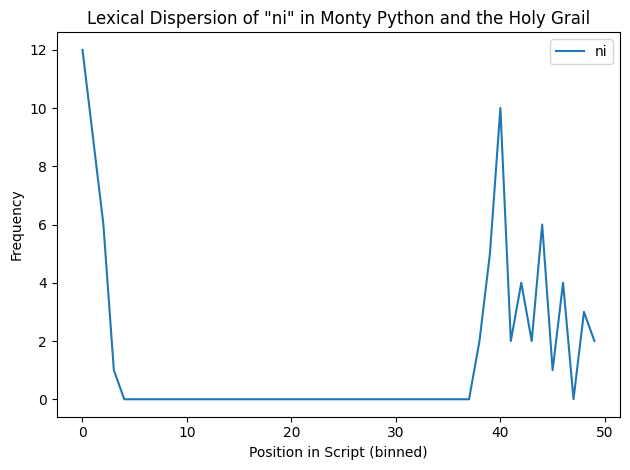

In [8]:
# Task 2: Plot a Histogram of How Often the Word 'Ni' Appears in the Monty Python Script

# Think of the script as a timeline split into 50 equal chunks. Each bar shows how often "ni" appears in that chunk.
# A cluster of bars tells you exactly where in the film  the Knights Who Say "Ni" appear.

plt.figure(figsize=(16, 4))
pd.DataFrame({'ni': locations('ni', grail)}).plot(title='Lexical Dispersion of "ni" in Monty Python and the Holy Grail')
plt.xlabel('Position in Script (binned)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

---

### **Exercise 3: Find the shortest sentence in any inaugural address from our corpus**

In [14]:
# Import Libraries and Load the Dataset (Inagural Addresses)
import os
from glob import glob

# Load all inaugural addresses
inaugural_filenames = sorted(glob('Text-Analysis/inaugural/*'))
labels = [os.path.splitext(os.path.basename(file))[0] for file in inaugural_filenames]

In [15]:
# Parse each document with SpaCy
inaugural_data = [nlp(open(documents).read()) for documents in inaugural_filenames]

In [16]:
# Find the Shortest Sentence Across all the Documents
shortest_sentence = None
shortest_length = float('inf')
shortest_president_address = None

for document, label in zip(inaugural_data, labels):
   for sentence in document.sents:
      if len(sentence) < shortest_length: 
         shortest_length = len(sentence)
         shortest_sentence = sentence
         shortest_president_address = label

print(f"President : {shortest_president_address}")
print(f"Length    : {shortest_length} tokens")
print(f"Sentence  : {shortest_sentence}")

President : 1901-McKinley
Length    : 3 tokens
Sentence  : It came.


---

### **Exercise 4: President With Lowest Proportion of Adjectives (POS Tagging)**

Out of all 29 inaugural addresses, which president used the fewest adjectives relative to their total words? Simpler/more direct speech = fewer adjectives.

In [18]:
# Load the Dataset into the Model and Labels
inaugural_Filenames = sorted(glob('Text-Analysis/inaugural/*'))
labels = [os.path.splitext(os.path.basename(file))[0] for file in inaugural_Filenames]

# Call the NLP Model to Tokenize, POS Tagm Dependency Parser, Named Entity Relationship the String - Part-Of-Speech (POS) Tagging happens here
inaugural_dataset = [nlp(open(document, errors='ignore').read()) for document in inaugural_Filenames] 

In [19]:
# Calculate adjective proportion per document by using Part-Of-Speech (POS) Tagging
adjective_proportions = []

for document in inaugural_dataset:
    total_words = len(document)
    adj_count   = len([token for token in document if token.pos_ == 'ADJ']) # POS Tagging
    proportion  = adj_count / total_words
    adjective_proportions.append(proportion)

# Build results into a DataFrame and sort the data
results = pd.DataFrame({ 'president'  : labels,'adj_proportion' : adjective_proportions }).sort_values('adj_proportion')

# Show bottom 5 (lowest adjective use)
print(results.head())

         president  adj_proportion
11  1945-Roosevelt        0.053599
16    1965-Johnson        0.054701
20     1981-Reagan        0.056951
28      2017-Trump        0.057525
27      2009-Obama        0.058439


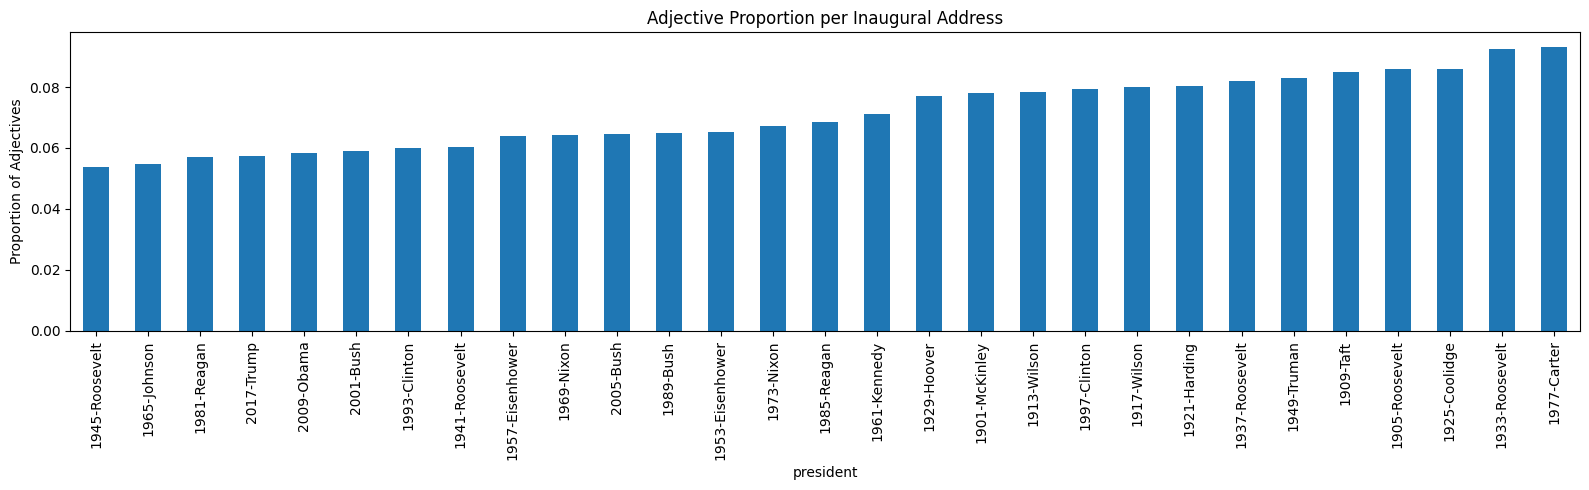

In [20]:
# Plot all presidents
results.set_index('president')['adj_proportion'].plot(
    kind='bar',
    figsize=(16, 5),
    title='Adjective Proportion per Inaugural Address'
)
plt.ylabel('Proportion of Adjectives')
plt.tight_layout()
plt.show()

---

### **Exercise 5: Find which Dickens novels are most semantically similar**

Use word vectors + similarity scores to find which of Dickens' novels are closest in meaning/style, the same technique used for the inaugural addresses similarity matrix.

In [22]:
import requests

# Download Dickens novels from Project Gutenberg (Online)
dickens_texts = {
    'Oliver Twist'        : 'https://www.gutenberg.org/files/730/730-0.txt',
    'A Tale of Two Cities': 'https://www.gutenberg.org/files/98/98-0.txt',
    'Great Expectations'  : 'https://www.gutenberg.org/files/1400/1400-0.txt',
    'A Christmas Carol'   : 'https://www.gutenberg.org/files/46/46-0.txt',
}

# Load and parse each novel
novels = {}
for title, url in dickens_texts.items():
    print(f"Loading {title}...")
    text = requests.get(url).text
    novels[title] = nlp(text[:50000])  # first 50k chars to keep it fast

Loading Oliver Twist...
Loading A Tale of Two Cities...
Loading Great Expectations...
Loading A Christmas Carol...


In [23]:
# Compute pairwise similarity
titles = list(novels.keys())        # ['Oliver Twist', 'Tale of Two Cities', ...]
documents = list(novels.values())   # [doc1, doc2, doc3, doc4]

# Compare every novel against every other novel
similarities = []
for document in documents:                   # Iterate through Each Novel
    row = []
    for other in documents:                  # Compare against Every novel
        score = document.similarity(other)   # Get similarity score (0 to 1)
        row.append(score)
    similarities.append(row)                 # Add row to grid

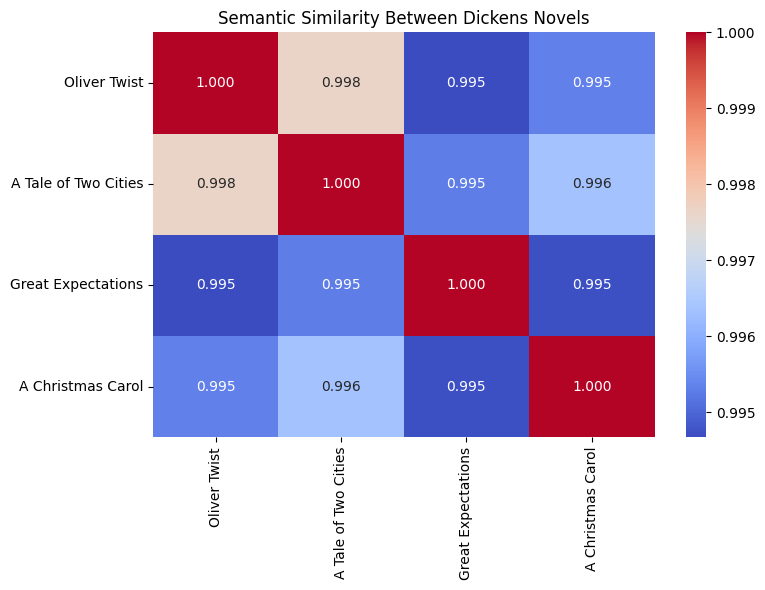

In [24]:
# Display as heatmap
import seaborn
similaritiesDf = pd.DataFrame( similarities, columns=titles, index=titles)

plt.figure(figsize=(8, 6))
seaborn.heatmap(similaritiesDf, annot=True, fmt='.3f', cmap='coolwarm')
plt.title('Semantic Similarity Between Dickens Novels')
plt.tight_layout()
plt.show()

---

### **N-Gram Language Model (Maximum Likelihood Estimator)**

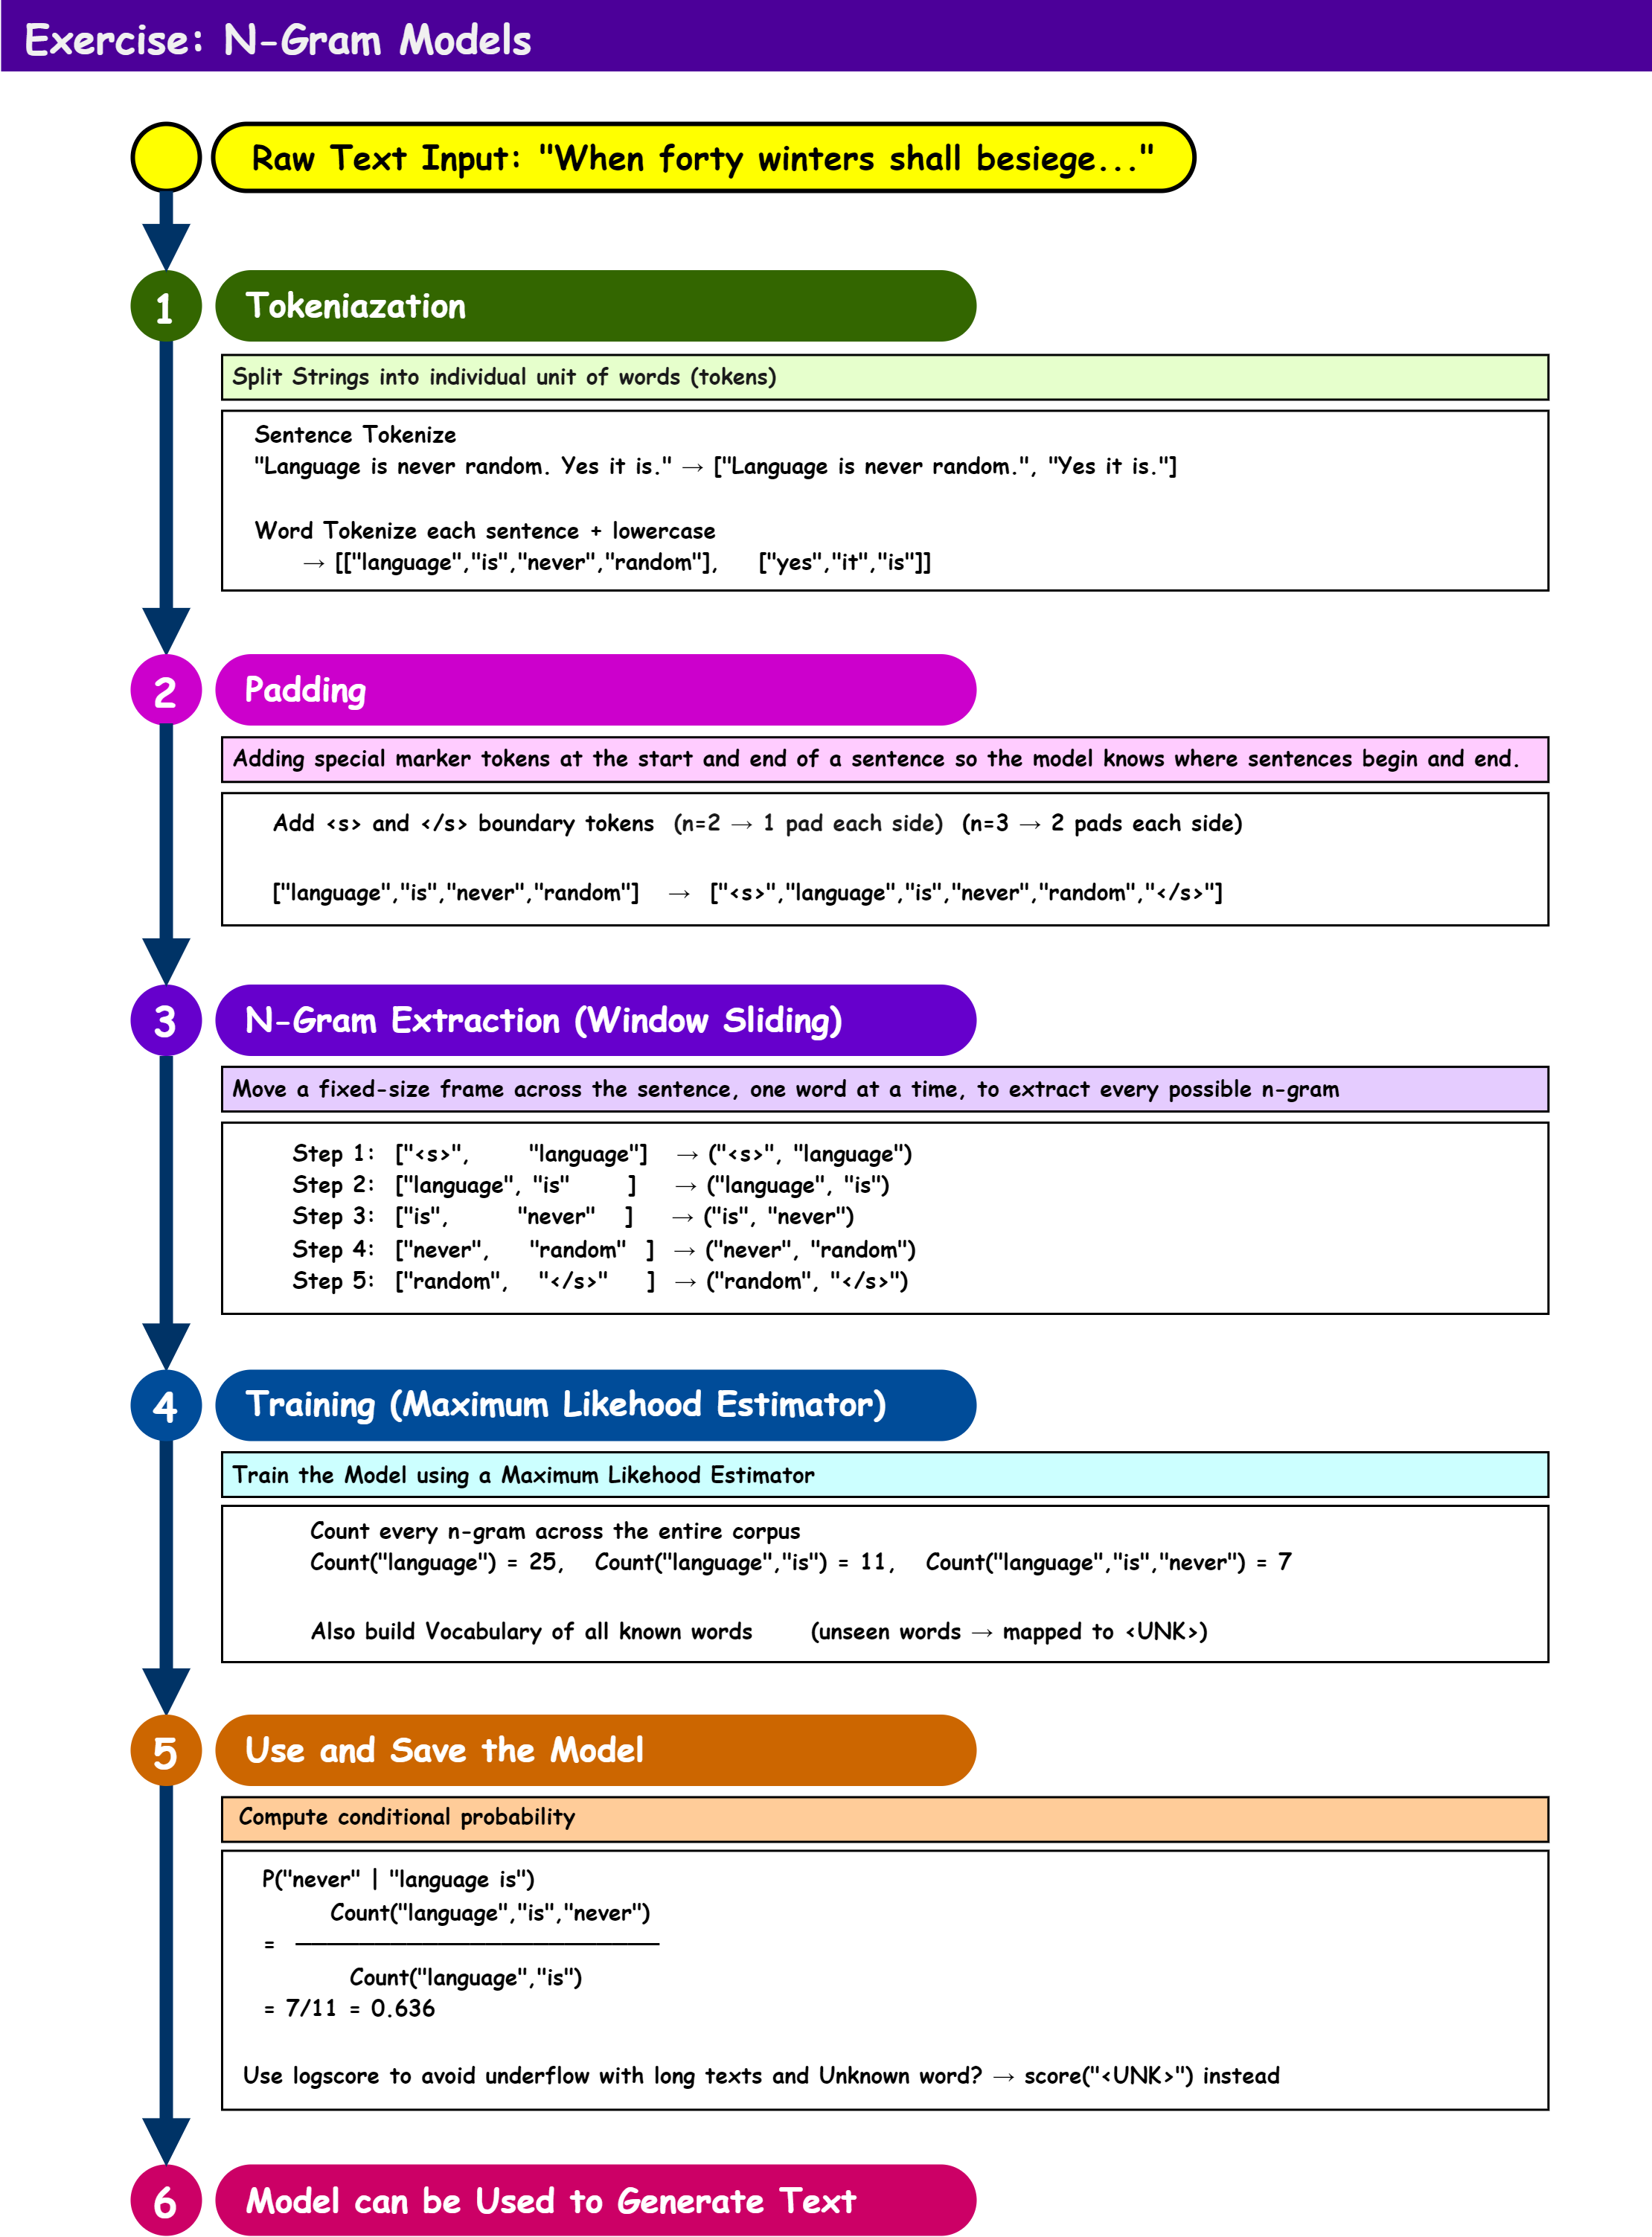